# 02 — Exploratory Data Analysis of the 5-Minute SOLETE Data

## Purpose

The first notebook examined SOLETE at 60-minute resolution. We now move to the
5-minute file to determine what additional temporal detail it preserves and
whether the same structural or measurement-quality issues remain visible.

This notebook asks:

1. Is the 5-minute timeline complete, chronological, and free of duplicate
   timestamps?
2. How do the two possible forecasting targets — solar PV power and wind
   power — behave at this finer resolution?
3. Which variables show suspicious ranges or systematic time-boundary
   behaviour?
4. Which relationships are useful for understanding the data before any
   forecasting model is designed?

The analysis remains non-destructive. Suspicious values are identified and
described, but no source measurement is corrected, removed, or imputed here.

## Data source

SOLETE contains meteorological measurements together with co-located wind and
solar photovoltaic generation from the SYSLAB facility in Denmark.

- Pombo, D. V., Gehrke, O., & Bindner, H. W. (2022), *SOLETE, a 15-month
  long holistic dataset including: Meteorology, co-located wind and solar PV
  power from Denmark with various resolutions*, Data in Brief, 42, 108046.
  DOI: `10.1016/j.dib.2022.108046`
- Dataset DOI: `10.11583/DTU.17040767`


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Locate the project root whether VS Code starts the kernel from the project
# directory or from notebooks/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_solete

DATASET_PATH = PROJECT_ROOT / "solete_dataset" / "SOLETE_Pombo_5min.h5"
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"SOLETE file not found: {DATASET_PATH}")

df = load_solete(DATASET_PATH)


## Dataset and temporal structure

Before using a high-resolution time series for forecasting, we need to verify
that its timestamp index behaves as expected. A missing or duplicated timestamp
could later break lag construction or create an incorrect forecast horizon.

We therefore check the complete observation period, missing measurements,
duplicate timestamps, chronological ordering, and the expected 5-minute grid.


In [2]:
expected_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="5min",
)

time_differences = df.index.to_series().diff().dropna()

overview = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "start_timestamp": df.index.min(),
    "end_timestamp": df.index.max(),
    "timezone": str(df.index.tz),
    "missing_measurements": int(df.isna().sum().sum()),
    "duplicate_timestamps": int(df.index.duplicated().sum()),
    "chronological": df.index.is_monotonic_increasing,
    "expected_5min_rows": len(expected_index),
    "missing_5min_timestamps": len(expected_index.difference(df.index)),
    "non_5min_intervals": int(
        (time_differences != pd.Timedelta(minutes=5)).sum()
    ),
}, name="5-minute SOLETE")

display(overview.to_frame("value"))
display(df.head(3))


,value
rows,131617
columns,11
start_timestamp,2018-06-01 00:00:00+00:00
end_timestamp,2019-09-01 00:00:00+00:00
timezone,UTC
missing_measurements,0
duplicate_timestamps,0
chronological,True
expected_5min_rows,131617
missing_5min_timestamps,0


,TEMPERATURE[degC],HUMIDITY[%],WIND_SPEED[m1s],WIND_DIR[deg],GHI[kW1m2],POA Irr[kW1m2],P_Gaia[kW],P_Solar[kW],Pressure[mbar],Azimuth[deg],Elevation[deg]
Timestamp,,,,,,,,,,,
2018-06-01 00:00:00+00:00,14.561204,0.7,1.293645,111.635452,0.0,0.0,0.046917,0.0,1017.559985,0.0,0.0
2018-06-01 00:05:00+00:00,14.487667,0.7,1.442333,91.236667,0.0,0.0,0.000267,0.0,1017.539990,0.0,0.0
2018-06-01 00:10:00+00:00,14.400000,0.7,1.408667,104.423333,0.0,0.0,0.000000,0.0,1017.493668,0.0,0.0


## Candidate forecasting targets

SOLETE contains two renewable-generation variables that could be forecast:

- `P_Solar[kW]` — photovoltaic generation;
- `P_Gaia[kW]` — Gaia wind-turbine generation.

The 60-minute exploration showed that the aggregated Gaia series was extremely
sparse. The 5-minute data allow us to test whether that behaviour persists at
the finer resolution before deciding whether wind power is suitable as a
second forecasting target.


In [3]:
target_columns = ["P_Solar[kW]", "P_Gaia[kW]"]

target_summary = pd.DataFrame({
    "mean_kW": df[target_columns].mean(),
    "median_kW": df[target_columns].median(),
    "max_kW": df[target_columns].max(),
    "zero_fraction": (df[target_columns] == 0).mean(),
    "nonzero_observations": (df[target_columns] > 0).sum(),
    "missing": df[target_columns].isna().sum(),
})

target_summary


,mean_kW,median_kW,max_kW,zero_fraction,nonzero_observations,missing
P_Solar[kW],0.987980,0.070956,7.715423,0.412583,77314,0
P_Gaia[kW],2.694643,0.985330,23.330538,0.294886,92805,0


## Measurement ranges and quality flags

Descriptive statistics are useful for detecting scale, skewness, clipping, and
obvious encoding issues. The checks below are screening rules rather than
automatic cleaning rules.

From the 60-minute exploration we already have reasons to examine humidity,
wind direction, and pressure carefully. At 5-minute resolution we can also see
whether suspicious values occur at particular times rather than randomly.


In [4]:
descriptive = df.describe().T[
    ["count", "mean", "std", "min", "50%", "max"]
].rename(columns={"50%": "median"})

quality_flags = pd.Series({
    "humidity < 0 or > 1": int(
        ((df["HUMIDITY[%]"] < 0) | (df["HUMIDITY[%]"] > 1)).sum()
    ),
    "wind direction outside [0, 360)": int(
        ((df["WIND_DIR[deg]"] < 0) | (df["WIND_DIR[deg]"] >= 360)).sum()
    ),
    "negative GHI": int((df["GHI[kW1m2]"] < 0).sum()),
    "negative POA irradiance": int((df["POA Irr[kW1m2]"] < 0).sum()),
    "negative wind power": int((df["P_Gaia[kW]"] < 0).sum()),
    "negative solar power": int((df["P_Solar[kW]"] < 0).sum()),
    "pressure outside 800–1100 mbar": int(
        ((df["Pressure[mbar]"] < 800) | (df["Pressure[mbar]"] > 1100)).sum()
    ),
}, name="flagged observations")

display(descriptive)
display(quality_flags.to_frame())


,count,mean,std,min,median,max
TEMPERATURE[degC],131617.0,11.936593,7.223151,-4.814333,12.509000,44.535452
HUMIDITY[%],131617.0,0.769125,0.158512,0.000000,0.800000,2.000000
WIND_SPEED[m1s],131617.0,3.591904,2.107510,0.000000,3.287333,24.393980
WIND_DIR[deg],131617.0,209.155515,72.642820,0.000000,215.920000,680.000000
GHI[kW1m2],131617.0,0.140382,0.218480,0.000000,0.011147,1.092413
POA Irr[kW1m2],131617.0,0.144382,0.245790,0.000000,0.009047,1.119663
P_Gaia[kW],131617.0,2.694643,3.382534,0.000000,0.985330,23.330538
P_Solar[kW],131617.0,0.987980,1.666584,0.000000,0.070956,7.715423
Pressure[mbar],131617.0,1013.775905,59.362014,974.262999,1010.903013,2034.519662
Azimuth[deg],131617.0,-2.131780,57.375601,-152.374530,0.000000,145.346370


,flagged observations
humidity < 0 or > 1,164
"wind direction outside [0, 360)",103
negative GHI,0
negative POA irradiance,0
negative wind power,0
negative solar power,0
pressure outside 800–1100 mbar,456


## Daily-boundary behaviour

The pressure values above 1100 mbar are not isolated random spikes: they occur
at the daily boundary. Because wind speed, wind direction, and Gaia power also
show unusually large values around some midnight observations, we inspect
pressure and wind-power boundary behaviour together.

This is still diagnosis only. The goal is to establish whether the pattern is
systematic enough to justify a later preprocessing rule.


In [5]:
midnight = (df.index.hour == 0) & (df.index.minute == 0)
pressure_high = df["Pressure[mbar]"] > 1100

# A simple neighbour comparison is appropriate for pressure because it is a
# linear variable. It estimates how far the midnight value jumps relative to
# the immediately surrounding 23:55 and 00:05 observations.
neighbor_pressure = (
    df["Pressure[mbar]"].shift(1) + df["Pressure[mbar]"].shift(-1)
) / 2

pressure_jump = (
    df.loc[midnight, "Pressure[mbar]"]
    - neighbor_pressure.loc[midnight]
).dropna()

# >12 kW is used only as an exploratory threshold for the extreme Gaia tail,
# not as a declaration that those observations are invalid.
gaia_high = df["P_Gaia[kW]"] > 12

boundary_summary = pd.Series({
    "pressure >1100 mbar": int(pressure_high.sum()),
    "pressure >1100 at midnight": int((pressure_high & midnight).sum()),
    "median midnight pressure jump (mbar)": pressure_jump.median(),
    "Gaia power >12 kW": int(gaia_high.sum()),
    "Gaia >12 kW at midnight": int((gaia_high & midnight).sum()),
    "maximum Gaia power at midnight (kW)": df.loc[midnight, "P_Gaia[kW]"].max(),
    "maximum Gaia power outside midnight (kW)": df.loc[~midnight, "P_Gaia[kW]"].max(),
}, name="daily-boundary diagnostics")

display(boundary_summary.to_frame("value"))

# One short window makes the discontinuity easier to understand than printing
# hundreds of anomalous rows.
display(
    df.loc[
        "2018-12-07 23:45:00+00:00":"2018-12-08 00:15:00+00:00",
        ["Pressure[mbar]", "WIND_SPEED[m1s]", "WIND_DIR[deg]", "P_Gaia[kW]"],
    ]
)


,value
pressure >1100 mbar,456.000000
pressure >1100 at midnight,456.000000
median midnight pressure jump (mbar),1000.000000
Gaia power >12 kW,51.000000
Gaia >12 kW at midnight,35.000000
maximum Gaia power at midnight (kW),23.330538
maximum Gaia power outside midnight (kW),12.509403


,Pressure[mbar],WIND_SPEED[m1s],WIND_DIR[deg],P_Gaia[kW]
Timestamp,,,,
2018-12-07 23:45:00+00:00,1000.0,8.767000,271.646667,11.498637
2018-12-07 23:50:00+00:00,1000.0,7.774333,267.076667,11.305783
2018-12-07 23:55:00+00:00,1000.0,7.612000,266.596667,10.959943
2018-12-08 00:00:00+00:00,2000.0,15.485953,560.197324,23.330538
2018-12-08 00:05:00+00:00,1000.0,7.339667,261.680000,11.373940
2018-12-08 00:10:00+00:00,1000.0,7.795667,268.310000,10.907083
2018-12-08 00:15:00+00:00,1000.0,7.524667,263.503333,11.104367


## Target–driver relationships

Same-timestamp relationships help us understand the measurements, but they are
**not forecasting results**. A strong contemporaneous correlation does not mean
that the corresponding variable can be used at a future forecast-valid time.

For example, measured irradiance at the future target timestamp would not be
known at forecast issue time unless it were itself forecast. This distinction
will become important when the forecasting protocol is designed.

Here we use the relationships only to check whether the two generation targets
behave consistently with their main physical drivers.


In [6]:
target_driver_relationships = pd.Series({
    "PV vs POA irradiance": df["P_Solar[kW]"].corr(df["POA Irr[kW1m2]"]),
    "PV vs GHI": df["P_Solar[kW]"].corr(df["GHI[kW1m2]"]),
    "PV vs source elevation": df["P_Solar[kW]"].corr(df["Elevation[deg]"]),
    "Wind power vs wind speed": df["P_Gaia[kW]"].corr(df["WIND_SPEED[m1s]"]),
}, name="Pearson correlation")

source_elevation_summary = pd.Series({
    "minimum elevation (deg)": df["Elevation[deg]"].min(),
    "maximum elevation (deg)": df["Elevation[deg]"].max(),
    "zero-elevation observations": int((df["Elevation[deg]"] == 0).sum()),
    "nonzero PV while elevation == 0": int(
        ((df["P_Solar[kW]"] > 0) & (df["Elevation[deg]"] == 0)).sum()
    ),
}, name="source elevation")

display(target_driver_relationships.to_frame())
display(source_elevation_summary.to_frame("value"))


,Pearson correlation
PV vs POA irradiance,0.995524
PV vs GHI,0.913074
PV vs source elevation,0.752715
Wind power vs wind speed,0.844912


,value
minimum elevation (deg),0.000000
maximum elevation (deg),58.263029
zero-elevation observations,61045.000000
nonzero PV while elevation == 0,10387.000000


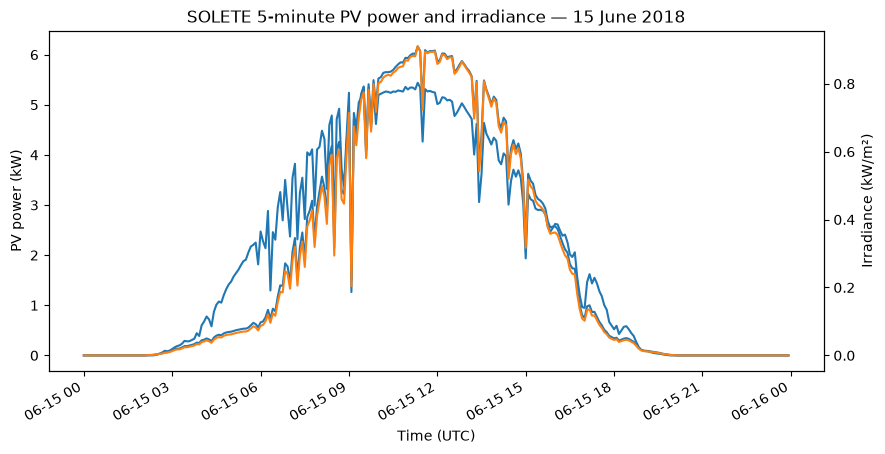

In [7]:
# A representative summer day shows how PV generation follows the daytime
# irradiance pattern at 5-minute resolution.
sample_day = df.loc[
    "2018-06-15",
    ["P_Solar[kW]", "GHI[kW1m2]", "POA Irr[kW1m2]"],
]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sample_day.index, sample_day["P_Solar[kW]"], label="PV power")
ax1.set_xlabel("Time (UTC)")
ax1.set_ylabel("PV power (kW)")

ax2 = ax1.twinx()
ax2.plot(sample_day.index, sample_day["GHI[kW1m2]"], label="GHI")
ax2.plot(sample_day.index, sample_day["POA Irr[kW1m2]"], label="POA irradiance")
ax2.set_ylabel("Irradiance (kW/m²)")

ax1.set_title("SOLETE 5-minute PV power and irradiance — 15 June 2018")
fig.autofmt_xdate()
plt.show()


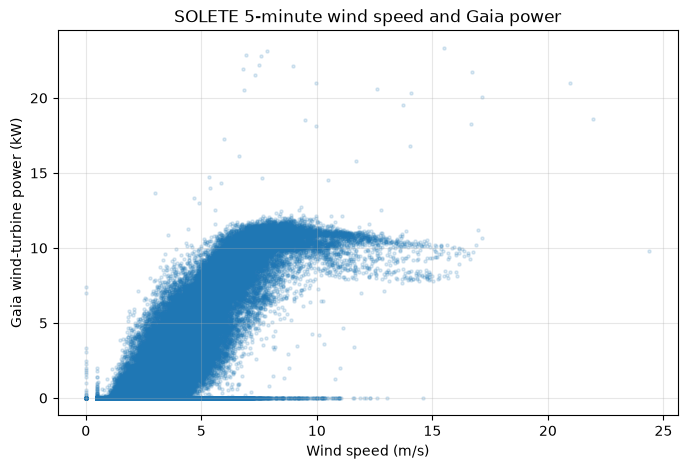

In [8]:
# Wind power should not be expected to vary linearly with wind speed. The
# scatter plot lets us see the turbine-like nonlinear relationship directly.
plt.figure(figsize=(8, 5))
plt.scatter(
    df["WIND_SPEED[m1s]"],
    df["P_Gaia[kW]"],
    s=5,
    alpha=0.15,
)
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Gaia wind-turbine power (kW)")
plt.title("SOLETE 5-minute wind speed and Gaia power")
plt.grid(alpha=0.3)
plt.show()


## Findings

The 5-minute SOLETE file contains 131,617 observations across the same 11
variables seen at 60-minute resolution. Its timestamp index is already
chronological, contains no duplicate timestamps, and follows a complete
5-minute grid without unexpected intervals or missing measurements.

### Candidate targets

Both renewable-generation variables are informative at this resolution.

`P_Solar[kW]` contains the expected day/night zero structure. `P_Gaia[kW]`,
however, is much more densely populated than it appeared in the 60-minute
file. This suggests that the extreme wind-power sparsity observed at
60-minute resolution is resolution-specific rather than evidence that the
wind target itself is unusable. Wind power therefore remains a plausible
second forecasting target and should be investigated further.

### Solar behaviour

PV power has a very strong same-timestamp relationship with plane-of-array
irradiance and a strong relationship with global horizontal irradiance. These
relationships confirm that the solar measurements are internally coherent,
but they are descriptive rather than evidence about future forecasting skill.

The source `Elevation[deg]` field never becomes negative and is exactly zero
for many observations, including some with non-zero PV generation. It should
therefore not automatically be treated as a conventional signed astronomical
solar-elevation angle.

### Wind behaviour

Gaia wind-turbine power has a strong, clearly nonlinear relationship with wind
speed. This is consistent with the type of relationship expected between wind
speed and turbine generation and supports continued investigation of wind
power as a forecasting target.

### Data-quality observations

Several source-data behaviours require later validation:

- humidity appears mainly to use a fractional scale rather than percentage
  points;
- some wind-direction values fall outside `[0°, 360°)` and need circular
  interpretation;
- pressure shows a highly systematic approximately +1000 mbar discontinuity
  at 00:00 UTC;
- unusually large Gaia power values are also concentrated around some midnight
  observations, so daily-boundary behaviour should be examined before
  modelling.

No raw source value is modified in this notebook.

## Next step

The 1-minute and 1-second SOLETE files will be examined next. Their finer
sampling can help determine whether the suspicious daily-boundary behaviour is
present in the underlying measurements or introduced by aggregation.

After the resolution-specific exploration is complete, the datasets can be
compared directly before selecting a forecasting resolution and defining any
preprocessing rules.
